# NYC Real Data
In response to a reviewer, we are testing each inflation method on COVID data in Manhattan and comparing the fits of the estimated parameters derived from different methods.



In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import glob
import os
import pickle
import syslog

import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
from numpy.random import uniform
import pandas as pd
from tqdm import tqdm

from epyfilter.eakf import eakf, enks, model_da
from epyfilter.simulate import simulate_data

### Load Empirical Data

/var/folders/zn/k_h7_jyn53z2q5c6jyqhbsym0000gn/T/ipykernel_61304/2518378060.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_long['Date'] = pd.to_datetime(df_long['Date'])


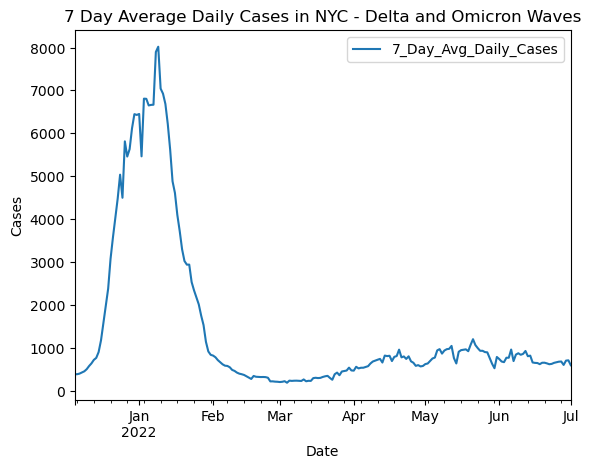

In [2]:
START_DATE = "12/05/2021"
END_DATE = "07/01/2022"
TIME_WINDOW_SIZE = 7
NYC_FIPS = 36061
RAW_CASE_URL = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/refs/heads/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_US.csv"

df = pd.read_csv(RAW_CASE_URL)
df = df.loc[df['FIPS'] == 36061]

df_long = pd.melt(df, id_vars=['UID', 'iso2', 'iso3', 'code3', 'FIPS', 'Admin2', 'Province_State', 'Country_Region', 'Lat', 'Long_', 'Combined_Key'], 
                  var_name='Date', value_name='Cases')
df_long['Date'] = pd.to_datetime(df_long['Date'])

# calculate daily cases and moving average
df_long['Daily_Cases'] = df_long.groupby('FIPS')['Cases'].diff().fillna(0)
df_long['7_Day_Avg_Daily_Cases'] = df_long['Daily_Cases'].rolling(window=7).mean()

# filter between START_DATE and END_DATE
df_long = df_long[(df_long['Date'] >= START_DATE) & (df_long['Date'] <= END_DATE)]
df_long.plot(x='Date', y='7_Day_Avg_Daily_Cases', title='7 Day Average Daily Cases in NYC - Delta and Omicron Waves', xlabel='Date', ylabel='Cases')
plt.show()

In [3]:
# NYC population
N = 1.596*10**6

alpha = 0.28365230839069

S0_lower = 0.3118602512099231
S0_upper = 0.588672776294887
S0 = 0.33

I0_lower = 0.004717584589197237
I0_upper = 0.020397018308864166
I0 = 2000

true_params = {
    'rt_0': 1.3,
    'rt_1': 4.8, 
    'midpoint': 100,
    'k': 0.2,
    'n_t': df_long.shape[0],
    't_I': 3.50,
    'N': N,
    'S0': S0 * N,
    'I0': I0
}

np.random.seed(1994)

data = simulate_data.simulate_data(**true_params, add_noise=True, noise_param=1/50)
real_cases = df_long['7_Day_Avg_Daily_Cases'].values / alpha
data.i_true = real_cases
data.i = real_cases

## Run EAKF and load EpiFilter/ EpiEstim outputs

In [4]:
def free_sim_re(kk, add_noise=False, burn_in_days=22):
    S = np.array([kk.data.S0 * np.ones(kk.m)])
    Ir = np.array([kk.data.I0 * np.ones(kk.m)])
    i = np.array([np.zeros(kk.m)])

    susc = np.array([x.S for x in kk.x_list])
    r0 = np.array([θ.beta * θ.t_I for θ in kk.θ_list])
    re = r0 * susc / kk.data.N

    for t in range(kk.data.beta.shape[0]):
        if t < burn_in_days:
            dSI = np.random.poisson(re[burn_in_days]/kk.data.t_I * Ir[t])
        else:
            dSI = np.random.poisson(re[t]/kk.data.t_I * Ir[t])
        dIR = np.random.poisson(Ir[t]/kk.data.t_I)

        S_new = np.clip(S[t]-dSI, 0, kk.data.N)
        I_new = np.clip(Ir[t]+dSI-dIR, 0, kk.data.N)

        S = np.append(S, [S_new], axis=0)
        Ir = np.append(Ir, [I_new], axis=0)
        i = np.append(i, [dSI], axis=0)
    
    kk.i_ppc_true = i
    if add_noise:
        i = i.astype("float64")
        obs_error_var = np.maximum(1.0, i[1:] ** 2 * kk.data.noise_param)
        obs_error_sample = np.random.normal(0, 1, size=(kk.data.n_t, kk.m))
        i[1:] += obs_error_sample * np.sqrt(obs_error_var)
        i = np.clip(i, 0,kk.data.N)

    kk.i_ppc = i

    return S, Ir, i

def free_sim_re_ks(kk, add_noise=False, burn_in_days=22):
    S = np.array([kk.data.S0 * np.ones(kk.eakf.m)])
    Ir = np.array([kk.data.I0 * np.ones(kk.eakf.m)])
    i = np.array([np.zeros(kk.eakf.m)])

    susc = np.array([x.S for x in kk.x_list])
    r0 = np.array([θ.beta * θ.t_I for θ in kk.θ_list])
    re = r0 * susc / kk.data.N

    for t in range(len(kk.θ_lag_list)):
        if t < burn_in_days:
            dSI = np.random.poisson(re[burn_in_days]/kk.data.t_I * Ir[t])
        else:
            dSI = np.random.poisson(re[t]/kk.data.t_I * Ir[t])
        dIR = np.random.poisson(Ir[t]/kk.data.t_I)

        S_new = np.clip(S[t]-dSI, 0, kk.data.N)
        I_new = np.clip(Ir[t]+dSI-dIR, 0, kk.data.N)

        S = np.append(S, [S_new], axis=0)
        Ir = np.append(Ir, [I_new], axis=0)
        i = np.append(i, [dSI], axis=0)
    
    kk.i_ppc_true = i
    if add_noise:
        i = i.astype("float64")
        obs_error_var = np.maximum(1.0, i[1:] ** 2 * kk.data.noise_param)
        obs_error_sample = np.random.normal(0, 1, size=(len(kk.x_list), kk.eakf.m))
        i[1:] += obs_error_sample * np.sqrt(obs_error_var)
        i = np.clip(i, 0,kk.data.N)

    kk.i_ppc = i

    return S, Ir, i

In [5]:
RUN_EAKF = False

if not RUN_EAKF:
    # load KF objects instead
    kf = pickle.load(open(f'eakf.pkl', 'rb'))
    kf_none = pickle.load(open('eakf_none.pkl', 'rb'))
    kf_fixed = pickle.load(open('eakf_fixed.pkl', 'rb'))
    ks = pickle.load(open('enks.pkl', 'rb'))

r0_mean = 2.0
burn_in = 14

b_low = (r0_mean - 1)/ 3.5
b_high = (r0_mean + 1) / 3.5
prior = {
            "beta": {
                "dist": uniform,
                "args": {
                    "low": b_low,
                    "high": b_high,
                    # "low": 0.2,
                    # "high": 1.7,
                },
            },
            "t_I": {
                "dist": "constant",
            }
        }

state_prior = {
    "S" : {
        "dist": uniform,
        "args": {
            "low": S0_lower,
            "high": S0_upper,
        }
    },
    "I" : {
        "dist": uniform,
        "args": {
            "low": I0_lower,
            "high": I0_upper,
        }
    }
}

if RUN_EAKF:
    n_ens = 300
    model = model_da.SIR_model(data)

    # adaptive
    kf = eakf.EnsembleAdjustmentKalmanFilter(model, m=n_ens)
    kf.filter(prior, inf_method="adaptive")

    # ensrs
    ks = enks.EnsembleSquareRootSmoother(kf)
    ks.smooth(window_size=10, plot=False)

    # no inflation
    kf_none = eakf.EnsembleAdjustmentKalmanFilter(model, m=n_ens)
    kf_none.filter(prior, inf_method="none")

    # fixed inflation
    kf_fixed = eakf.EnsembleAdjustmentKalmanFilter(model, m=n_ens)
    kf_fixed.filter(prior, inf_method="constant", lam_fixed=1.05)

In [6]:
def load_epiestim_post(path="nyc_real_data_epiestim_posterior.csv"):
    epiestim_df = pd.read_csv(path)
    return epiestim_df

def load_epifilter_post(path="nyc_real_data_epifilter_posterior.csv"):
    epifilter_df = pd.read_csv(path)
    return epifilter_df

def compute_reliability_epiestim(epiestim_ppc_df, percentiles):
    prop_list = []

    epiestim_ppc_array = np.array(epiestim_ppc_df["sample"+np.arange(1, 301).astype(str)].iloc[1:])
    for p in percentiles:
        lower = np.quantile(epiestim_ppc_array, q=[(1-p/100)/2, 1-(1-p/100)/2], axis=1)[0, :]
        upper = np.quantile(epiestim_ppc_array, q=[(1-p/100)/2, 1-(1-p/100)/2], axis=1)[1, :]

        pp = (lower <= kf.data.i[:len(epiestim_ppc_array)]) & (kf.data.i[:len(epiestim_ppc_array)] <= upper)
        prop_list.append(np.mean(pp[np.where(kf.data.i[:len(epiestim_ppc_array)] > 5)]))

    return prop_list

def compute_reliability_epifilter(epifilter_ppc_df, percentiles):
    sample_cols = [f'sample{i}' for i in range(1, 301)]
    truth = data.i

    prop_list = []
    for p in percentiles:
        lower = np.quantile(epifilter_ppc_df[sample_cols], q=[(1-p/100)/2, 1-(1-p/100)/2], axis=1)[0, :]
        upper = np.quantile(epifilter_ppc_df[sample_cols], q=[(1-p/100)/2, 1-(1-p/100)/2], axis=1)[1, :]

        pp = (lower <= kf.data.i) & (kf.data.i <= upper)
        prop_list.append(np.mean(pp))

    return prop_list


percentiles = np.arange(2.5, 100, 2.5)

# load epiestim and compute reliability
epiestim_df = load_epiestim_post()
epiestim_ppc_df = pd.read_csv("nyc_real_data_epiestim_ippc.csv")
epiestim_ppc_df2 = pd.read_csv("nyc_real_data_epifilter_ippc2.csv")

epiestim_reliability = compute_reliability_epiestim(epiestim_ppc_df, percentiles)

# load epifilter and compute reliability
epifilter_df = pd.read_csv("nyc_real_data_epifilter_posterior_eta_0.02.csv")
epifilter_ppc_df = pd.read_csv("nyc_real_data_epifilter_ippc2_eta_0.02.csv")

epifilter_reliability = compute_reliability_epifilter(epifilter_ppc_df, percentiles)


In [7]:
# compute ppd and reliabilty for EAKF methods
if RUN_EAKF:
    # compute ppd using Re
    kf.free_sim(np.asarray([θ.beta for θ in kf.θ_list]), add_noise=True)
    ks.free_sim(np.asarray([θ.beta for θ in ks.θ_lag_list]), add_noise=True)
    kf_none.free_sim(np.asarray([θ.beta for θ in kf_none.θ_list]), add_noise=True)
    kf_fixed.free_sim(np.asarray([θ.beta for θ in kf_fixed.θ_list]), add_noise=True)
    free_sim_re(kf, add_noise=True, burn_in_days=burn_in)
    free_sim_re_ks(ks, add_noise=True, burn_in_days=burn_in)
    free_sim_re(kf_none, add_noise=True, burn_in_days=burn_in)
    free_sim_re(kf_fixed, add_noise=True, burn_in_days=burn_in)

    percentiles = np.arange(2.5, 100, 2.5)
    kf.compute_reliability(percentiles)
    ks.compute_reliability(percentiles)
    kf_none.compute_reliability(percentiles)
    kf_fixed.compute_reliability(percentiles)

np.max(kf.i_ppc)

np.float64(66277.09135744692)

In [8]:
if RUN_EAKF:
    path = "./"
    kf.save_data(path=path, name='eakf')
    kf_fixed.save_data(path=path, name='eakf_fixed')
    kf_none.save_data(path=path, name='eakf_none')
    ks.save_data(path=path, name='enks')


## Figure 4

/var/folders/zn/k_h7_jyn53z2q5c6jyqhbsym0000gn/T/ipykernel_61304/3763816581.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


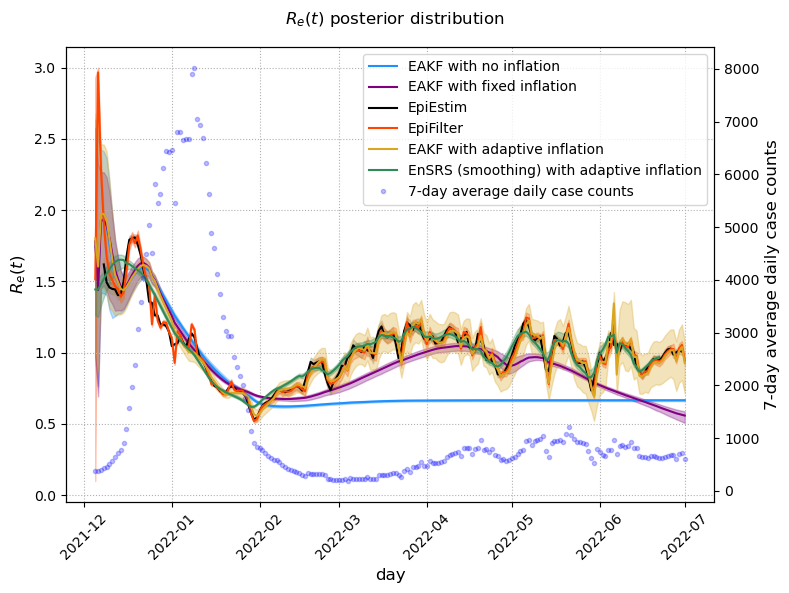

In [9]:
def compute_re_ci_mean(kf, smooth=False, confidence_level=95):
    if smooth:
        susc = np.array([x.S for x in kf.x_list])
        array = np.array([θ.beta*θ.t_I for θ in kf.θ_lag_list])
        array = array * susc / kf.eakf.data.N
    else:
        susc = np.array([x.S for x in kf.x_list])
        array = np.array([θ.beta * θ.t_I for θ in kf.θ_list])
        array = array * susc / kf.data.N
    ci = np.percentile(array, [100 - confidence_level, confidence_level], axis=1)
    mean = np.mean(array, axis=1)
    return ci, mean

def plot_re_posterior(save=False, fname='fig4'):
    # compute mean and cis
    ci_no, mean_no = compute_re_ci_mean(kf_none)
    ci_fixed, mean_fixed = compute_re_ci_mean(kf_fixed)
    ci_adapt, mean_adapt = compute_re_ci_mean(kf)
    ci_smooth, mean_smooth = compute_re_ci_mean(ks, smooth=True)

    fig, ax = plt.subplots()
    fig.suptitle(r"$R_e(t)$ posterior distribution")
    fig.set_figheight(6)
    fig.set_figwidth(8)

    ax.fill_between(df_long['Date'], ci_no[0,:], ci_no[1,:], color='dodgerblue', alpha=0.3)
    ax.plot(df_long['Date'], mean_no, color="dodgerblue", label=r"EAKF with no inflation")

    ax.fill_between(df_long['Date'], ci_fixed[0,:], ci_fixed[1,:], color='purple', alpha=0.3)
    ax.plot(df_long['Date'], mean_fixed, color="purple", label=r"EAKF with fixed inflation")

    ax.fill_between(df_long['Date'].iloc[3:208], epiestim_df['Quantile.0.025(R)'], epiestim_df['Quantile.0.975(R)'], color='grey', alpha=0.3)
    ax.plot(df_long['Date'].iloc[3:208], epiestim_df['Mean(R)'], color='black', label=r"EpiEstim")

    ax.fill_between(df_long['Date'], epifilter_df['lower'], epifilter_df['upper'], color='orangered', alpha=0.3)
    ax.plot(df_long['Date'], epifilter_df['mean'], color='orangered', label=r"EpiFilter")

    ax.fill_between(df_long['Date'], ci_adapt[0,:], ci_adapt[1,:], color='goldenrod', alpha=0.3)
    ax.plot(df_long['Date'], mean_adapt, color="goldenrod", label=r"EAKF with adaptive inflation")

    ax.fill_between(df_long['Date'][:-9], ci_smooth[0,:], ci_smooth[1,:], color='seagreen', alpha=0.3)
    ax.plot(df_long['Date'][:-9], mean_smooth, color="seagreen", label=r"EnSRS (smoothing) with adaptive inflation")


    # plot cases in background
    ax2 = ax.twinx()
    ax2.plot(df_long['Date'], df_long['7_Day_Avg_Daily_Cases'], '.', alpha=0.25, color='blue', label='7-day average daily case counts')
    ax2.set_ylabel('7-day average daily case counts', fontsize=12)

    ax.set_xlabel("day", fontsize=12)
    ax.set_ylabel(r"$R_e(t)$", fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.grid(linestyle='dotted')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    fig.tight_layout()

    if save:
        fig.savefig(f'{fname}.png', bbox_inches='tight', dpi=300)
        fig.savefig(f"{fname}.pdf", bbox_inches='tight', transparent=True)

plot_re_posterior(save=True, fname='fig4')
plt.show()


## Figure 5

In [10]:
def _zoom_plot(ax_sub, date1 = '2022-01-01', date2 = '2022-01-15'):
    dates = df_long['Date']

    sub_dates = dates.loc[(dates >= date1)  & (dates <= date2)]
    sub_idx = ((dates >= date1) & (dates <= date2)).values

    sub_df = epiestim_ppc_df2.loc[sub_idx].reset_index(drop=True)

    truth = data.i[sub_idx]

    # fig, ax_sub = plt.subplots()

    ax_sub.plot(sub_dates, sub_df['sample' + np.arange(1, 301).astype(str)], color="orangered", alpha=0.01)
    ax_sub.plot(sub_dates, np.mean(sub_df['sample' + np.arange(1, 301).astype(str)], axis=1), color="orangered")
    ax_sub.plot(sub_dates, truth, "x", color='black', markersize=2)

    ax_sub.grid(linestyle='dotted')
    date_form = mdates.DateFormatter("%m-%d")
    ax_sub.xaxis.set_major_formatter(date_form)
    ax_sub.set_xticklabels(ax_sub.get_xticklabels(), rotation=45)
    ax_sub.set_facecolor('white')

    rect = patches.FancyBboxPatch(
        (0, 0), 1, 1, transform=ax_sub.transAxes,
        facecolor='white', edgecolor='none', boxstyle='round,pad=0.1',
        zorder=1
    )
    ax_sub.add_patch(rect)

    return ax_sub


def plot_ppd(title=None, save=False, fname='fig5'):
    fs = 10
    dates = df_long['Date']
    truth = data.i

    fig = plt.figure(figsize=(7.5*2, 8.75*1.5))

    gs = gridspec.GridSpec(3, 3, height_ratios=[1, 1, 1], width_ratios=[1, 1, 1])

    # no inflation
    ax1 = plt.subplot(gs[0,0])
    ax1.plot(dates, kf_none.i_ppc[1:], color="dodgerblue", alpha=0.02)
    ax1.plot(dates, np.mean(kf_none.i_ppc[1:], axis=1), color='blue')
    ax1.plot(dates, truth, "x", color='firebrick', markersize=2)
    ax1.set_title('EAKF with no inflation', fontsize=fs)
    ax1.set_ylabel('daily case counts', fontsize=fs)

    # fixed inflation
    ax2 = plt.subplot(gs[1,0], sharey=ax1)
    ax2.plot(dates, kf_fixed.i_ppc[1:], color="purple", alpha=0.02)
    ax2.plot(dates, np.mean(kf_fixed.i_ppc[1:], axis=1), color='purple')
    ax2.plot(dates, truth, "x", color='firebrick', markersize=2)
    ax2.set_title('EAKF with fixed inflation', fontsize=fs)
    ax2.set_ylabel('daily case counts', fontsize=fs)

    # adaptive inflation
    ax3 = plt.subplot(gs[0,1], sharey=ax1)
    ax3.plot(dates, kf.i_ppc[1:], color="goldenrod", alpha=0.02)
    ax3.plot(dates, np.mean(kf.i_ppc[1:], axis=1), color='orange')
    ax3.plot(dates, truth, "x", color='firebrick', markersize=2)
    ax3.set_title('EAKF with adaptive inflation', fontsize=fs)
    plt.setp(ax3.get_yticklabels(), visible=False)

    # ensrs
    ax4 = plt.subplot(gs[1,1], sharey=ax1)
    ax4.plot(dates[:-9], ks.i_ppc[1:], color="seagreen", alpha=0.02)
    ax4.plot(dates[:-9], np.mean(ks.i_ppc[1:], axis=1), color='mediumseagreen')
    ax4.plot(dates, truth, "x", color='firebrick', markersize=2)
    ax4.set_title('EnSRS (smoothing) with adaptive inflation', fontsize=fs)
    plt.setp(ax4.get_yticklabels(), visible=False)

    # epiestim
    ax5 = plt.subplot(gs[2,0], sharey=ax1)
    ax5.plot(dates.iloc[epiestim_ppc_df['day']], epiestim_ppc_df['sample' + np.arange(1, 301).astype(str)], color="gray", alpha=0.01)
    ax5.plot(dates.iloc[epiestim_ppc_df['day']], np.mean(epiestim_ppc_df['sample' + np.arange(1, 301).astype(str)], axis=1), color="black")
    ax5.plot(dates, truth, "x", color='firebrick', markersize=2)
    ax5.set_title('EpiEstim', fontsize=fs)
    ax5.set_xlabel('day', fontsize=fs)
    ax5.set_ylabel('daily case counts', fontsize=fs)

    # epifilter
    ax6 = plt.subplot(gs[2,1], sharey=ax1)
    ax6.plot(dates[1:-1], epifilter_ppc_df['sample' + np.arange(1, 301).astype(str)][1:-1], color="orangered", alpha=0.01)
    ax6.plot(dates[1:-1], np.mean(epifilter_ppc_df['sample' + np.arange(1, 301).astype(str)], axis=1)[1:-1], color="orangered")
    ax6.plot(dates, truth, "x", color='firebrick', markersize=2)
    ax6.set_title('EpiFilter', fontsize=fs)
    ax6.set_xlabel('day', fontsize=fs)
    plt.setp(ax6.get_yticklabels(), visible=False)

    # reliability
    ax7 = plt.subplot(gs[:,2])
    ax7.plot(percentiles / 100, kf_none.prop_list, ".-", color='dodgerblue')
    ax7.plot(percentiles / 100, kf_fixed.prop_list, ".-", color='purple')
    ax7.plot(percentiles / 100, kf.prop_list, ".-", color='goldenrod')
    ax7.plot(percentiles / 100, ks.prop_list, ".-", color='seagreen')
    ax7.plot(percentiles / 100, epiestim_reliability, ".-", color='black')
    ax7.plot(percentiles / 100, epifilter_reliability, ".-", color='orangered')
    ax7.plot([0, 1], [0, 1], '--', color="k", label="Perfect coverage")

    # zoomed plot
    inset = inset_axes(ax6, width="40%", height="40%", loc='upper right', borderpad=2)
    date1 = '2022-01-01'
    date2 = '2022-01-15'
    _zoom_plot_ax = _zoom_plot(ax_sub=inset, date1=date1, date2=date2)
    # inset.set_facecolor('aliceblue')
    inset.grid(linestyle='dotted')

    # Add a rectangle to highlight the zoomed region on the main plot (ax6)
    zoom_start = pd.to_datetime(date1)
    zoom_end = pd.to_datetime(date2)
    ymin, ymax = inset.get_ylim()

    rect = patches.Rectangle(
        (zoom_start, ymin),
        zoom_end - zoom_start,
        ymax - ymin,
        linewidth=1.5,
        edgecolor='black',
        facecolor='none',
        zorder=10
    )
    ax6.add_patch(rect)

    ax7.set_title("Reliability", fontsize=fs)
    ax7.set_ylabel("coverage", fontsize=fs)
    ax7.set_xlabel("quantile", fontsize=fs)
    ax7.legend()

    ax7.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax7.grid(which='minor', linestyle='--', alpha=0.5)
    ax7.grid(linestyle='dotted')

    for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
        ax.grid(linestyle='dotted')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

    plt.subplots_adjust(hspace = 0.5, wspace=0.3)

    if title:
        fig.suptitle(title, fontsize=12)
    else:
        fig.suptitle('Posterior predictive distributions', fontsize=12)

    # add legend
    blank_line = mlines.Line2D([], [], color='none')
    red_line = mlines.Line2D([], [], color='firebrick', marker='x', linestyle='None', markersize=2) 
    blue_line = mlines.Line2D([], [], color='dodgerblue', linestyle='-')
    purple_line = mlines.Line2D([], [], color='purple', linestyle='-')
    yellow_line = mlines.Line2D([], [], color='goldenrod', linestyle='-')
    green_line = mlines.Line2D([], [], color='seagreen', linestyle='-')
    black_line = mlines.Line2D([], [], color='black', linestyle='-')
    teal_line = mlines.Line2D([], [], color='orangered', linestyle='-')

    handles = [red_line, blank_line, blue_line, yellow_line, purple_line, green_line, black_line, teal_line]
    labels = ['Data', '', 'EAKF with no inflation', 'EAKF with adaptive inflation', 'EAKF with fixed inflation', 'EnSRS (smoothing) with adaptive inflation', 'EpiEstim', 'EpiFilter']
    fig.legend(handles, labels,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.05),  # Pushes legend below figure
           ncol=4,
           fontsize=8,
           title_fontsize=9,
           frameon=True,
           borderpad=0.5
          )

    plt.tight_layout()

    if save:
        fig.savefig(f'{fname}.png', bbox_inches='tight', dpi=300)
        fig.savefig(f"{fname}.eps", format='eps', bbox_inches='tight', transparent=True)
        fig.savefig(f"{fname}.pdf", bbox_inches='tight', transparent=True)

In [1]:
plot_ppd(save=True, fname='fig5')
plt.show()

NameError: name 'plot_ppd' is not defined